<a href="https://colab.research.google.com/github/mahalak2004/Machine-learning/blob/main/PCA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

First 5 rows of dataset:
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  
0      9.4      5.0  
1      9.8      5

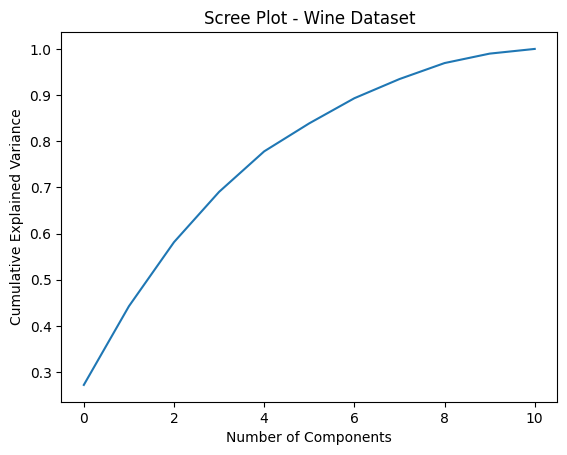

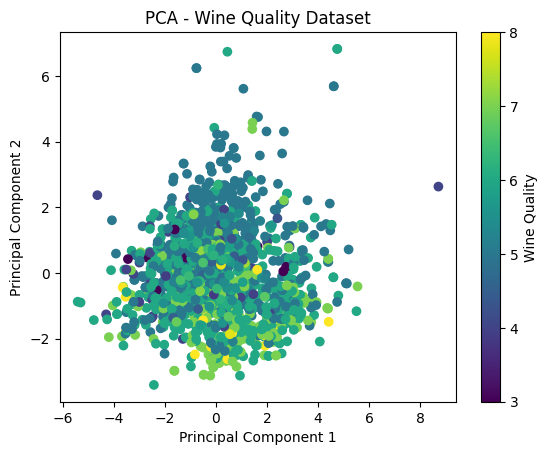

In [1]:
# ==========================================
# PCA Experiment - Wine Quality Dataset
# ==========================================

# Step 1: Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Step 2: Load Dataset (comma separated)
data = pd.read_csv("WineQuality.csv")

print("First 5 rows of dataset:")
print(data.head())

print("\nShape of dataset:", data.shape)

# Step 3: Separate Features and Target
X = data.drop("quality", axis=1)
y = data["quality"]

print("\nNumber of Features:", X.shape[1])

# Step 4: Standardize the Data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Step 5: Apply PCA (2 Components)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("\nOriginal Shape:", X.shape)
print("Reduced Shape:", X_pca.shape)

# Step 6: Explained Variance
print("\nExplained Variance Ratio:")
print(pca.explained_variance_ratio_)

print("Total Variance Captured:",
      np.sum(pca.explained_variance_ratio_))

# Step 7: Show Principal Components (Loadings)
pc_df = pd.DataFrame(
    pca.components_,
    columns=X.columns,
    index=["PC1", "PC2"]
)

print("\nPrincipal Component Loadings:")
print(pc_df)

# Step 8: Scree Plot (All Components)
pca_full = PCA()
pca_full.fit(X_scaled)

plt.figure()
plt.plot(np.cumsum(pca_full.explained_variance_ratio_))
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Scree Plot - Wine Dataset")
plt.show()

# Step 9: PCA 2D Visualization
plt.figure()
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA - Wine Quality Dataset")
plt.colorbar(scatter, label="Wine Quality")
plt.show()